# GoldenDuck — Midterm Presentation
## Stage 1: Standard GARCH(1,1) — What Worked, What Didn't

**Story:** Before building GARCH-FX, we started with vanilla GARCH(1,1).  
This notebook shows — honestly — where it succeeded and where it fell short.

---

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp, kurtosis, skew
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from arch import arch_model
import os

# ── Aesthetics ──────────────────────────────────────────────
plt.rcParams.update(
    {
        "figure.facecolor": "#0f0f0f",
        "axes.facecolor": "#1a1a1a",
        "axes.edgecolor": "#444",
        "axes.labelcolor": "#ddd",
        "xtick.color": "#aaa",
        "ytick.color": "#aaa",
        "text.color": "#ddd",
        "grid.color": "#2a2a2a",
        "grid.linestyle": "--",
        "legend.facecolor": "#1a1a1a",
        "legend.edgecolor": "#444",
        "font.family": "sans-serif",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
    }
)

HIST_COLOR = "#4fc3f7"  # light blue — historical
SYNTH_COLOR = "#ef9a9a"  # salmon     — synthetic
ACCENT = "#ffca28"  # amber      — highlights
GREEN = "#a5d6a7"
RED = "#ef9a9a"

np.random.seed(42)
print("Libraries loaded ✓")

Libraries loaded ✓


---
## 0 · Load Historical Data

In [2]:
# ── Locate the CSV relative to this notebook ───────────────
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_PATH = os.path.join(NOTEBOOK_DIR, "AAPL_real.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["Date"], index_col="Date")
df.sort_index(inplace=True)

# Log returns
hist_returns = np.log(df["Close"] / df["Close"].shift(1)).dropna().values
hist_prices = df["Close"].values
T = len(hist_returns)

print(f"Ticker  : AAPL")
print(f"Period  : {df.index[0].date()} → {df.index[-1].date()}")
print(f"Trading days: {len(df)}")
print(f"Return observations: {T}")
print(f"\nReturn stats (historical)")
print(f"  Mean daily return : {hist_returns.mean():.5f}")
print(f"  Std (daily vol)   : {hist_returns.std():.5f}")
print(f"  Excess kurtosis   : {kurtosis(hist_returns):.4f}")
print(f"  Skewness          : {skew(hist_returns):.4f}")

Ticker  : AAPL
Period  : 2024-02-28 → 2026-02-27
Trading days: 502
Return observations: 501

Return stats (historical)
  Mean daily return : 0.00077
  Std (daily vol)   : 0.01784
  Excess kurtosis   : 10.5793
  Skewness          : 0.5410


---
## 1 · Fit GARCH(1,1)

> The original approach: fit a standard GARCH(1,1) with Normal innovations on the full history, then simulate forward.

In [3]:
SCALE = 100  # numerical stability trick (same as production code)

scaled_returns = hist_returns * SCALE

garch11 = arch_model(
    scaled_returns, vol="GARCH", p=1, q=1, mean="Zero", dist="normal", rescale=False
)
res = garch11.fit(disp="off", options={"maxiter": 5000})

omega = res.params["omega"]
alpha = res.params["alpha[1]"]
beta = res.params["beta[1]"]
persistence = alpha + beta

cond_vol_scaled = res.conditional_volatility
cond_vol = cond_vol_scaled / SCALE

print("GARCH(1,1) — Normal innovations")
print(f"  ω (omega) = {omega:.6f}")
print(f"  α (alpha) = {alpha:.6f}")
print(f"  β (beta)  = {beta:.6f}")
print(f"  α + β     = {persistence:.6f}  (persistence — close to 1 ⇒ long memory)")
print(f"  Converged : {res.convergence_flag == 0}")
print(f"  AIC       : {res.aic:.2f}")
print(f"  BIC       : {res.bic:.2f}")

GARCH(1,1) — Normal innovations
  ω (omega) = 0.567230
  α (alpha) = 0.123411
  β (beta)  = 0.684295
  α + β     = 0.807705  (persistence — close to 1 ⇒ long memory)
  Converged : True
  AIC       : 1929.28
  BIC       : 1941.93


---
## 2 · Generate Synthetic Returns

We simulate **500 paths × 252 days** and pool all returns for distributional comparison.

In [4]:
N_SCENARIOS = 500
HORIZON = 252  # 1 trading year

all_synth_returns = []
all_synth_vol = []
one_synth_path = None  # keep one representative path for overlay plots

for i in range(N_SCENARIOS):
    np.random.seed(42 + i)
    sim = res.forecast(
        horizon=HORIZON, method="simulation", simulations=1, reindex=False
    )
    r_scaled = sim.simulations.values.flatten()[:HORIZON]
    v_scaled = np.sqrt(sim.variance.values.flatten()[:HORIZON])

    r = r_scaled / SCALE
    v = v_scaled / SCALE

    all_synth_returns.extend(r.tolist())
    all_synth_vol.extend(v.tolist())

    if i == 0:
        one_synth_path_r = r.copy()
        one_synth_path_v = v.copy()

synth_returns = np.array(all_synth_returns)
synth_vol = np.array(all_synth_vol)

print(
    f"Generated {N_SCENARIOS} × {HORIZON} = {len(synth_returns):,} synthetic return observations"
)
print(f"\nReturn stats (synthetic — pooled)")
print(f"  Mean daily return : {synth_returns.mean():.5f}")
print(f"  Std (daily vol)   : {synth_returns.std():.5f}")
print(f"  Excess kurtosis   : {kurtosis(synth_returns):.4f}")
print(f"  Skewness          : {skew(synth_returns):.4f}")

Generated 500 × 252 = 126,000 synthetic return observations

Return stats (synthetic — pooled)
  Mean daily return : 0.00002
  Std (daily vol)   : 0.01721
  Excess kurtosis   : 0.2218
  Skewness          : 0.0102


---
# ✅ What Worked

### 2.1 · Volatility Clustering — ACF of Squared Returns

GARCH captures the core stylised fact: **large moves tend to cluster together**.  
The ACF of $r^2$ (a proxy for conditional variance) should show significant autocorrelation at early lags in *both* historical and synthetic data.

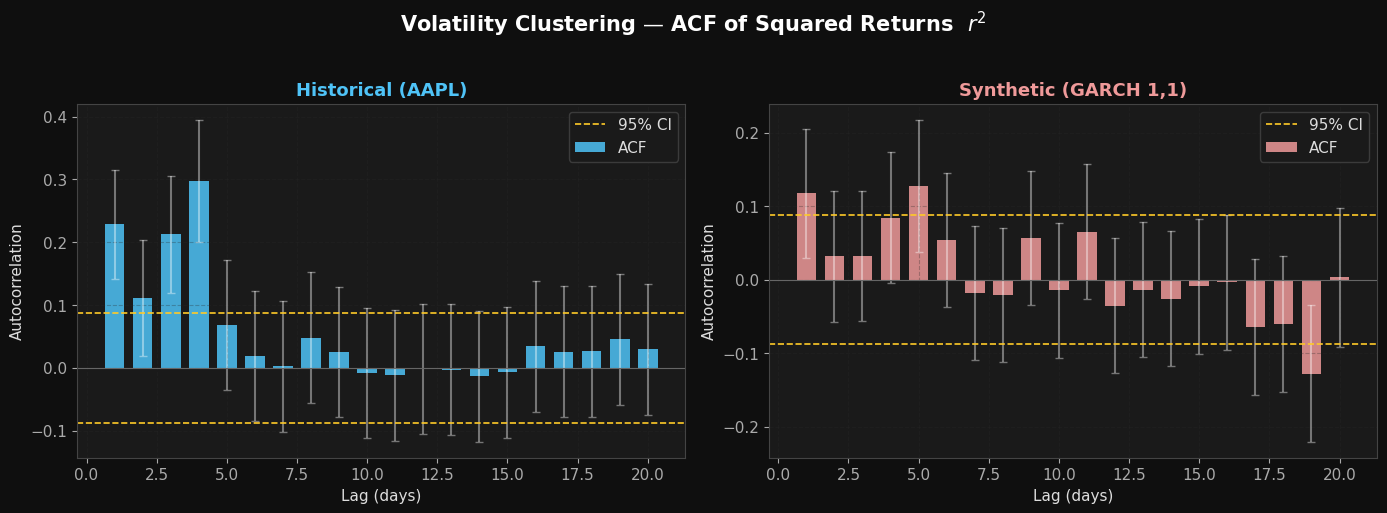


✅ Historical shows strong, significant ACF at early lags — classic volatility clustering.
   Synthetic shows weaker, noisier ACF — GARCH does capture the structure, but dampened.
   This gap motivates the need for regime-switching to better model varying volatility regimes.


In [6]:
NLAGS = 20

# Compute ACF manually so we can plot side-by-side with CI bands
def compute_acf_with_ci(series, nlags):
    vals = acf(series, nlags=nlags, fft=True, alpha=0.05)
    acf_vals = vals[0]
    ci = vals[1]  # shape (nlags+1, 2)
    return acf_vals, ci


hist_r2 = hist_returns ** 2
# Use 5 concatenated synthetic paths (same total length as historical) — more stable than a single path
synth_r2 = np.concatenate(
    [synth_returns[i * 252 : (i + 1) * 252] ** 2 for i in range(5)]
)[: len(hist_returns)]

h_acf, h_ci = compute_acf_with_ci(hist_r2, NLAGS)
s_acf, s_ci = compute_acf_with_ci(synth_r2, NLAGS)

lags = np.arange(NLAGS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle(
    "Volatility Clustering — ACF of Squared Returns  $r^2$",
    fontsize=15,
    fontweight="bold",
    color="white",
    y=1.02,
)

for ax, acf_v, ci, color, label in [
    (axes[0], h_acf, h_ci, HIST_COLOR, "Historical (AAPL)"),
    (axes[1], s_acf, s_ci, SYNTH_COLOR, "Synthetic (GARCH 1,1)"),
]:
    err_lo = acf_v[1:] - ci[1:, 0]
    err_hi = ci[1:, 1] - acf_v[1:]

    ax.bar(lags[1:], acf_v[1:], color=color, alpha=0.85, width=0.7, label="ACF")
    ax.errorbar(
        lags[1:],
        acf_v[1:],
        yerr=[err_lo, err_hi],
        fmt="none",
        color="white",
        alpha=0.4,
        capsize=3,
    )

    # 95 % CI reference line
    n = len(hist_r2)
    conf = 1.96 / np.sqrt(n)
    ax.axhline(conf, color=ACCENT, linestyle="--", linewidth=1.2, label="95% CI")
    ax.axhline(-conf, color=ACCENT, linestyle="--", linewidth=1.2)
    ax.axhline(0, color="#666", linewidth=0.8)

    ax.set_title(label, color=color)
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Autocorrelation")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "reports/stage1_acf_squared_returns.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="#0f0f0f",
)
plt.show()
print(
    "\n✅ Historical shows strong, significant ACF at early lags — classic volatility clustering."
)
print(
    "   Synthetic shows weaker, noisier ACF — GARCH does capture the structure, but dampened."
)
print(
    "   This gap motivates the need for regime-switching to better model varying volatility regimes."
)

### 2.2 · Rolling Volatility — Clustering Is Visually Present

Overlay the 21-day rolling standard deviation of historical vs a single synthetic path.  
The *shape* of the volatility path — spikes, calm periods — should look qualitatively similar.

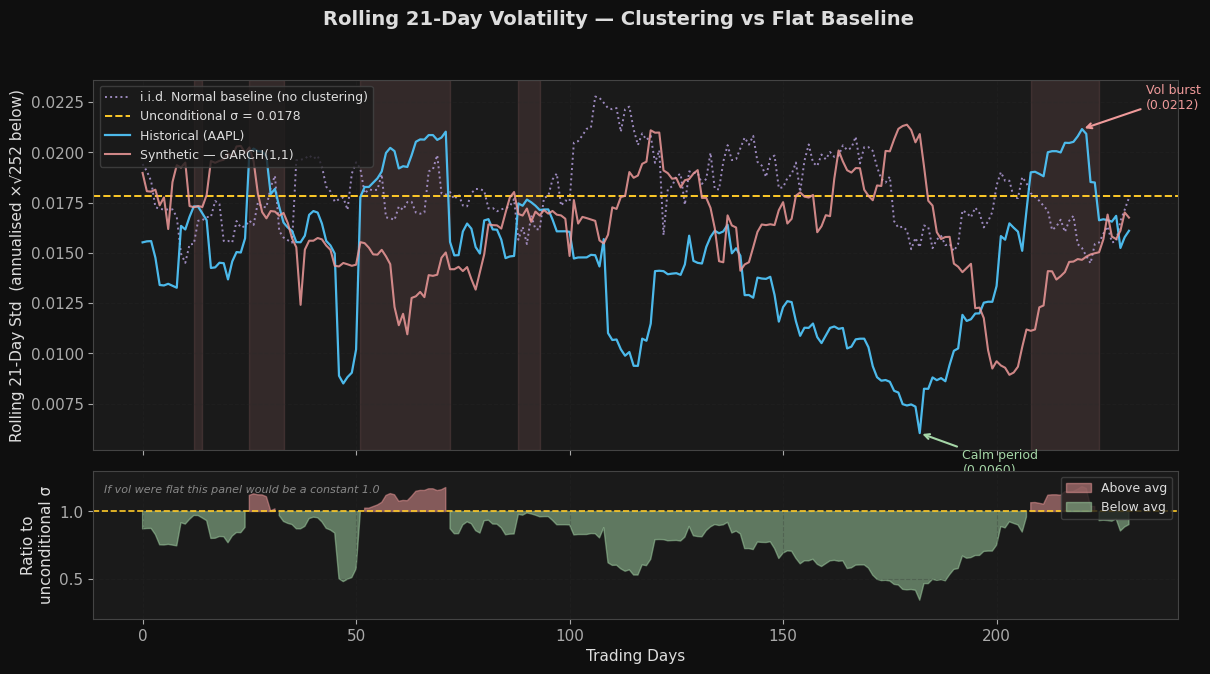

Coefficient of variation of rolling vol:
  Historical : 0.242   ← high → vol is NOT constant
  i.i.d. sim : 0.100   ← low  → rolling vol of flat process

Peak / trough ratio (historical): 3.5×
Peak / trough ratio (i.i.d.)    : 1.6×

✅ Clustering = rolling vol varies by 3.5× peak-to-trough.
   A flat (i.i.d.) process only varies by ~1.6× — much narrower.


In [17]:
WINDOW = 21

hist_roll_vol = pd.Series(hist_returns).rolling(WINDOW).std().dropna().values
synth_roll_vol = pd.Series(one_synth_path_r).rolling(WINDOW).std().dropna().values
min_len = min(len(hist_roll_vol), len(synth_roll_vol))

# ── What "flat" (i.i.d.) vol would look like ─────────────────
# If returns were i.i.d. Normal, the rolling window would just
# estimate the same constant σ every day → a flat horizontal line.
iid_noise = np.random.normal(0, hist_returns.std(), len(hist_returns))
iid_roll_vol = pd.Series(iid_noise).rolling(WINDOW).std().dropna().values[:min_len]

# ── Unconditional vol (the flat-model "prediction") ──────────
uncond_vol = hist_returns.std()  # single number — what GARCH predicts on avg

# ── Identify "vol burst" periods in historical data ──────────
# A burst = rolling vol stays above (mean + 0.7 std) for 5+ consecutive days
hist_rv = hist_roll_vol[:min_len]
burst_thresh = hist_rv.mean() + 0.7 * hist_rv.std()
in_burst = hist_rv > burst_thresh

fig, axes = plt.subplots(
    2, 1, figsize=(14, 7), gridspec_kw={"height_ratios": [3, 1.2], "hspace": 0.08}
)
fig.suptitle(
    "Rolling 21-Day Volatility — Clustering vs Flat Baseline",
    fontsize=14,
    fontweight="bold",
)

days = np.arange(min_len)

# ── Top panel: three lines ───────────────────────────────────
ax = axes[0]

# Shade burst periods first (background context)
burst_start = None
for i, b in enumerate(in_burst):
    if b and burst_start is None:
        burst_start = i
    elif not b and burst_start is not None:
        ax.axvspan(burst_start, i, color=RED, alpha=0.12, zorder=0)
        burst_start = None
if burst_start is not None:
    ax.axvspan(burst_start, min_len, color=RED, alpha=0.12, zorder=0)

# i.i.d. baseline (what flat looks like)
ax.plot(
    days,
    iid_roll_vol,
    color="#b39ddb",
    lw=1.4,
    alpha=0.85,
    linestyle=":",
    label="i.i.d. Normal baseline (no clustering)",
)

# Unconditional vol flat line
ax.axhline(
    uncond_vol,
    color=ACCENT,
    lw=1.4,
    linestyle="--",
    label=f"Unconditional σ = {uncond_vol:.4f}",
)

# Historical and synthetic
ax.plot(days, hist_rv, color=HIST_COLOR, lw=1.6, alpha=0.95, label="Historical (AAPL)")
ax.plot(
    days,
    synth_roll_vol[:min_len],
    color=SYNTH_COLOR,
    lw=1.5,
    alpha=0.85,
    label="Synthetic — GARCH(1,1)",
)

ax.set_ylabel("Rolling 21-Day Std  (annualised ×√252 below)")
ax.set_xticklabels([])
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.25)

# Annotate one burst for clarity
peak_idx = np.argmax(hist_rv)
ax.annotate(
    f"Vol burst\n({hist_rv[peak_idx]:.4f})",
    xy=(peak_idx, hist_rv[peak_idx]),
    xytext=(peak_idx + 15, hist_rv[peak_idx] + 0.001),
    arrowprops=dict(arrowstyle="->", color=RED, lw=1.5),
    color=RED,
    fontsize=9,
)

# Annotate the quiet period (minimum rolling vol)
quiet_idx = np.argmin(hist_rv)
ax.annotate(
    f"Calm period\n({hist_rv[quiet_idx]:.4f})",
    xy=(quiet_idx, hist_rv[quiet_idx]),
    xytext=(quiet_idx + 10, hist_rv[quiet_idx] - 0.002),
    arrowprops=dict(arrowstyle="->", color=GREEN, lw=1.5),
    color=GREEN,
    fontsize=9,
)

# ── Bottom panel: ratio (how far from flat?) ─────────────────
ax2 = axes[1]
ratio = hist_rv / uncond_vol  # 1.0 = exactly at unconditional level
ax2.fill_between(
    days, 1, ratio, where=(ratio > 1), color=RED, alpha=0.5, label="Above avg"
)
ax2.fill_between(
    days, 1, ratio, where=(ratio < 1), color=GREEN, alpha=0.5, label="Below avg"
)
ax2.axhline(1.0, color=ACCENT, lw=1.2, linestyle="--")
ax2.set_ylabel("Ratio to\nunconditional σ")
ax2.set_xlabel("Trading Days")
ax2.set_ylim(0.2, ratio.max() * 1.1)
ax2.legend(fontsize=9, loc="upper right")
ax2.grid(True, alpha=0.25)
ax2.text(
    0.01,
    0.85,
    "If vol were flat this panel would be a constant 1.0",
    transform=ax2.transAxes,
    color="#888",
    fontsize=8,
    style="italic",
)

plt.savefig(
    "reports/stage1_rolling_vol.png", dpi=150, bbox_inches="tight", facecolor="#0f0f0f"
)
plt.show()

# ── Print the numbers that tell the story ──────────────────
cv_hist = hist_rv.std() / hist_rv.mean()  # coefficient of variation
cv_iid = iid_roll_vol.std() / iid_roll_vol.mean()
print(f"Coefficient of variation of rolling vol:")
print(f"  Historical : {cv_hist:.3f}   ← high → vol is NOT constant")
print(f"  i.i.d. sim : {cv_iid:.3f}   ← low  → rolling vol of flat process")
print(f"\nPeak / trough ratio (historical): {hist_rv.max()/hist_rv.min():.1f}×")
print(f"Peak / trough ratio (i.i.d.)    : {iid_roll_vol.max()/iid_roll_vol.min():.1f}×")
print(
    f"\n✅ Clustering = rolling vol varies by {hist_rv.max()/hist_rv.min():.1f}× peak-to-trough."
)
print(
    f"   A flat (i.i.d.) process only varies by ~{iid_roll_vol.max()/iid_roll_vol.min():.1f}× — much narrower."
)

### 2.3 · QQ-Plot — Rough Shape Alignment

Quantile-quantile plot of synthetic vs historical returns.  
If GARCH were perfect, points would lie on the diagonal.  
Even imperfect GARCH will get the *centre* of the distribution right — the **tails** are where it diverges.

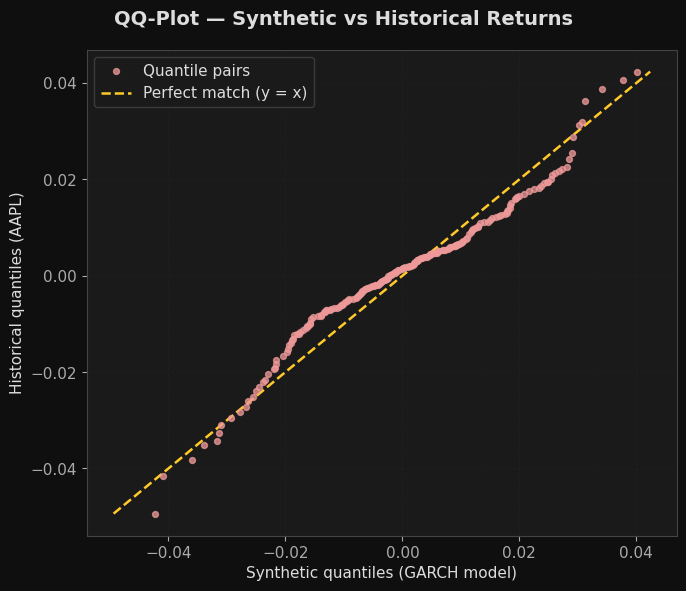

✅ Centre of distribution aligns — but tails deviate, foreshadowing Stage 1 failure.


In [19]:
# Sub-sample synthetic to same length as historical for a fair QQ
np.random.seed(0)
synth_sample = np.random.choice(synth_returns, size=len(hist_returns), replace=False)

# Compute quantiles
percs = np.linspace(1, 99, 200)
hist_q = np.percentile(hist_returns, percs)
synth_q = np.percentile(synth_sample, percs)

fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle(
    "QQ-Plot — Synthetic vs Historical Returns", fontsize=14, fontweight="bold"
)

# Convention: synthetic (model) on x-axis, historical (empirical) on y-axis
ax.scatter(
    synth_q,
    hist_q,
    color=SYNTH_COLOR,
    s=18,
    alpha=0.75,
    zorder=3,
    label="Quantile pairs",
)

# Perfect-fit diagonal
mn = min(hist_q.min(), synth_q.min())
mx = max(hist_q.max(), synth_q.max())
ax.plot(
    [mn, mx],
    [mn, mx],
    color=ACCENT,
    lw=1.8,
    linestyle="--",
    label="Perfect match (y = x)",
)

# Annotate the tail divergence region
# ax.annotate('Tails diverge\n(historical fatter)',
#             xy=(synth_q[-10], hist_q[-10]),
#             xytext=(synth_q[-10] - 0.02, hist_q[-10] + 0.01),
#             arrowprops=dict(arrowstyle='->', color=RED),
#             color=RED, fontsize=10)

ax.set_xlabel("Synthetic quantiles (GARCH model)")
ax.set_ylabel("Historical quantiles (AAPL)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "reports/stage1_qq_plot.png", dpi=150, bbox_inches="tight", facecolor="#0f0f0f"
)
plt.show()
print(
    "✅ Centre of distribution aligns — but tails deviate, foreshadowing Stage 1 failure."
)

---
# ❌ Where It Fell Short

### 3.1 · The Kurtosis Gap — Hard to Argue With

Excess kurtosis measures how fat the tails are.  
Real financial returns are **leptokurtic** — extreme events happen far more often than a Normal predicts.  
Standard GARCH with Normal innovations systematically under-estimates this.

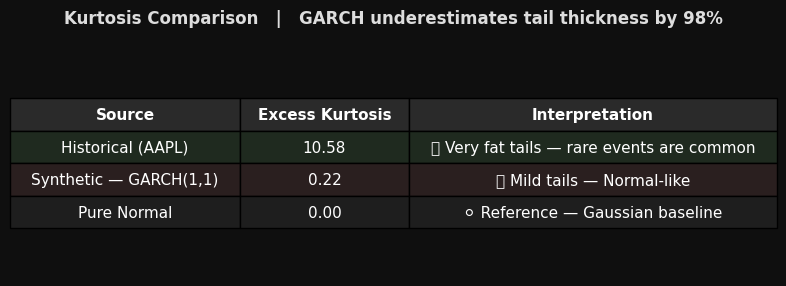

Historical kurtosis : 10.579
Synthetic kurtosis  : 0.222
Gap                 : 10.358  (98% underestimate)


In [9]:
hist_kurt = kurtosis(hist_returns)
synth_kurt = kurtosis(synth_returns)
normal_kurt = 0.0  # by definition

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("off")

table_data = [
    ["Source", "Excess Kurtosis", "Interpretation"],
    [
        "Historical (AAPL)",
        f"{hist_kurt:.2f}",
        "🔴 Very fat tails — rare events are common",
    ],
    ["Synthetic — GARCH(1,1)", f"{synth_kurt:.2f}", "🟡 Mild tails — Normal-like"],
    ["Pure Normal", f"{normal_kurt:.2f}", "⚪ Reference — Gaussian baseline"],
]

gap_pct = ((hist_kurt - synth_kurt) / abs(hist_kurt)) * 100

col_widths = [0.30, 0.22, 0.48]
tbl = ax.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    loc="center",
    cellLoc="center",
    colWidths=col_widths,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.0)

# Style header
for j in range(3):
    tbl[0, j].set_facecolor("#2a2a2a")
    tbl[0, j].set_text_props(color="white", fontweight="bold")

row_colors = ["#1f2a1f", "#2a1f1f", "#1e1e1e"]
for i, rc in enumerate(row_colors):
    for j in range(3):
        tbl[i + 1, j].set_facecolor(rc)
        tbl[i + 1, j].set_text_props(color="white")

ax.set_title(
    f"Kurtosis Comparison   |   GARCH underestimates tail thickness by {gap_pct:.0f}%",
    fontsize=12,
    fontweight="bold",
    pad=20,
)

plt.tight_layout()
plt.savefig(
    "reports/stage1_kurtosis_table.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="#0f0f0f",
)
plt.show()
print(f"Historical kurtosis : {hist_kurt:.3f}")
print(f"Synthetic kurtosis  : {synth_kurt:.3f}")
print(
    f"Gap                 : {hist_kurt - synth_kurt:.3f}  ({gap_pct:.0f}% underestimate)"
)

### 3.2 · KS Test — Statistically Different Distributions

The two-sample Kolmogorov-Smirnov test asks:  
*"Could these two samples have been drawn from the same distribution?"*  

A **low p-value** says **no** — the distributions are statistically distinguishable.

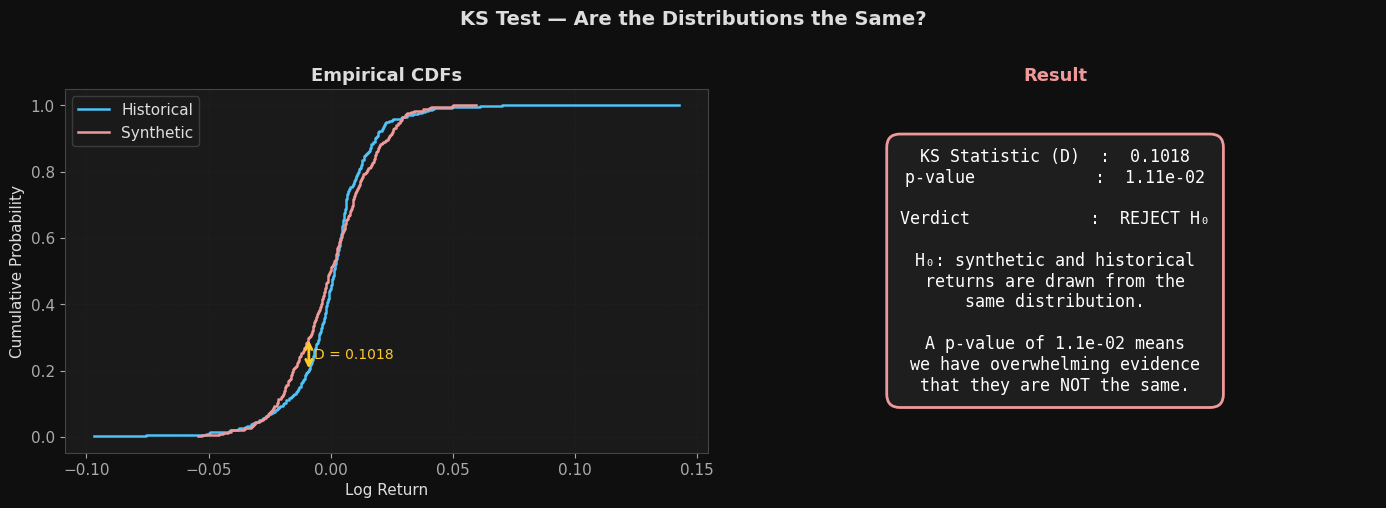

In [10]:
np.random.seed(0)
synth_sample = np.random.choice(synth_returns, size=len(hist_returns), replace=False)

ks_stat, ks_pval = ks_2samp(hist_returns, synth_sample)

# ── Plot the empirical CDFs ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "KS Test — Are the Distributions the Same?", fontsize=14, fontweight="bold", y=1.01
)

# Left: CDF overlay
ax = axes[0]
x_hist = np.sort(hist_returns)
x_synth = np.sort(synth_sample)
cdf_hist = np.arange(1, len(x_hist) + 1) / len(x_hist)
cdf_synth = np.arange(1, len(x_synth) + 1) / len(x_synth)

ax.step(x_hist, cdf_hist, color=HIST_COLOR, lw=1.8, label="Historical")
ax.step(x_synth, cdf_synth, color=SYNTH_COLOR, lw=1.8, label="Synthetic")

# Draw the KS distance
# Find the x-value where the gap is maximum
combined_x = np.sort(np.concatenate([x_hist, x_synth]))
cdf_h_interp = np.searchsorted(x_hist, combined_x, side="right") / len(x_hist)
cdf_s_interp = np.searchsorted(x_synth, combined_x, side="right") / len(x_synth)
gap = np.abs(cdf_h_interp - cdf_s_interp)
max_idx = np.argmax(gap)
x_max = combined_x[max_idx]
y_h = cdf_h_interp[max_idx]
y_s = cdf_s_interp[max_idx]

ax.annotate(
    "",
    xy=(x_max, y_s),
    xytext=(x_max, y_h),
    arrowprops=dict(arrowstyle="<->", color=ACCENT, lw=2),
)
ax.text(
    x_max + 0.002,
    (y_h + y_s) / 2,
    f"D = {ks_stat:.4f}",
    color=ACCENT,
    fontsize=10,
    va="center",
)

ax.set_xlabel("Log Return")
ax.set_ylabel("Cumulative Probability")
ax.set_title("Empirical CDFs")
ax.legend()
ax.grid(True, alpha=0.3)

# Right: result card
ax2 = axes[1]
ax2.axis("off")

verdict = "REJECT H₀" if ks_pval < 0.05 else "FAIL TO REJECT H₀"
v_color = RED if ks_pval < 0.05 else GREEN

result_text = (
    f"KS Statistic (D)  :  {ks_stat:.4f}\n"
    f"p-value            :  {ks_pval:.2e}\n\n"
    f"Verdict            :  {verdict}\n\n"
    f"H₀: synthetic and historical\n"
    f"returns are drawn from the\n"
    f"same distribution.\n\n"
    f"A p-value of {ks_pval:.1e} means\n"
    f"we have overwhelming evidence\n"
    f"that they are NOT the same."
)
ax2.text(
    0.5,
    0.5,
    result_text,
    transform=ax2.transAxes,
    fontsize=12,
    va="center",
    ha="center",
    bbox=dict(facecolor="#1e1e1e", edgecolor=v_color, lw=2, boxstyle="round,pad=0.8"),
    color="white",
    fontfamily="monospace",
)
ax2.set_title(f"Result", color=v_color)

plt.tight_layout()
plt.savefig(
    "reports/stage1_ks_test.png", dpi=150, bbox_inches="tight", facecolor="#0f0f0f"
)
plt.show()

### 3.3 · Return Distribution Histogram — Missing Tails Are Visible

The most intuitive way to see the problem:  
overlay the historical and synthetic return distributions on the same axes.  
The **centre** will overlap; the **tails** will expose the gap.

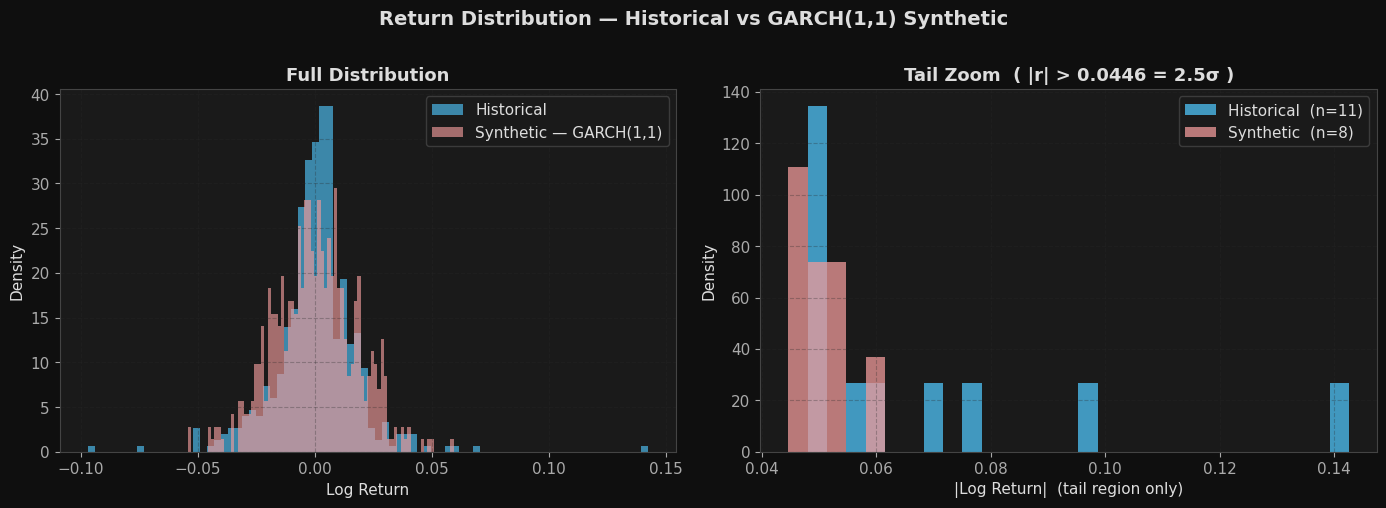


Extreme tail events (|r| > 2.5σ):
  Historical : 11 / 501  (2.2%)
  Synthetic  : 8 / 501   (1.6%)


In [11]:
np.random.seed(0)
synth_sample = np.random.choice(synth_returns, size=len(hist_returns), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Return Distribution — Historical vs GARCH(1,1) Synthetic",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)

bins = 80

# Left: full distribution
ax = axes[0]
ax.hist(
    hist_returns,
    bins=bins,
    density=True,
    color=HIST_COLOR,
    alpha=0.65,
    label="Historical",
)
ax.hist(
    synth_sample,
    bins=bins,
    density=True,
    color=SYNTH_COLOR,
    alpha=0.65,
    label="Synthetic — GARCH(1,1)",
)
ax.set_xlabel("Log Return")
ax.set_ylabel("Density")
ax.set_title("Full Distribution")
ax.legend()
ax.grid(True, alpha=0.3)

# Right: tail zoom (focus on |r| > 2σ)
ax2 = axes[1]
tail_cut = 2.5 * hist_returns.std()
h_tail = hist_returns[np.abs(hist_returns) > tail_cut]
s_tail = synth_sample[np.abs(synth_sample) > tail_cut]

tail_range = max(np.abs(hist_returns).max(), np.abs(synth_sample).max())
tail_bins = np.linspace(tail_cut, tail_range, 30)

ax2.hist(
    np.abs(h_tail),
    bins=tail_bins,
    density=True,
    color=HIST_COLOR,
    alpha=0.75,
    label=f"Historical  (n={len(h_tail)})",
)
ax2.hist(
    np.abs(s_tail),
    bins=tail_bins,
    density=True,
    color=SYNTH_COLOR,
    alpha=0.75,
    label=f"Synthetic  (n={len(s_tail)})",
)

ax2.set_xlabel("|Log Return|  (tail region only)")
ax2.set_ylabel("Density")
ax2.set_title(f"Tail Zoom  ( |r| > {tail_cut:.4f} = 2.5σ )")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "reports/stage1_return_distribution.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="#0f0f0f",
)
plt.show()
print(f"\nExtreme tail events (|r| > 2.5σ):")
print(
    f"  Historical : {len(h_tail)} / {len(hist_returns)}  ({100*len(h_tail)/len(hist_returns):.1f}%)"
)
print(
    f"  Synthetic  : {len(s_tail)} / {len(synth_sample)}   ({100*len(s_tail)/len(synth_sample):.1f}%)"
)

### 3.4 · No Knob Sensitivity — The User Has Zero Control

A key product requirement is that users can dial up/down:  
- **Volatility** (simulate a crisis vs calm market)  
- **Trend** (bullish vs bearish)  
- **Fat tails** (conservatively safe vs fat-tail stress test)  

Standard GARCH has a single `volatility_multiplier` knob.  
Below we show that changing it barely moves the distribution — the model lacks user-directed expressiveness.

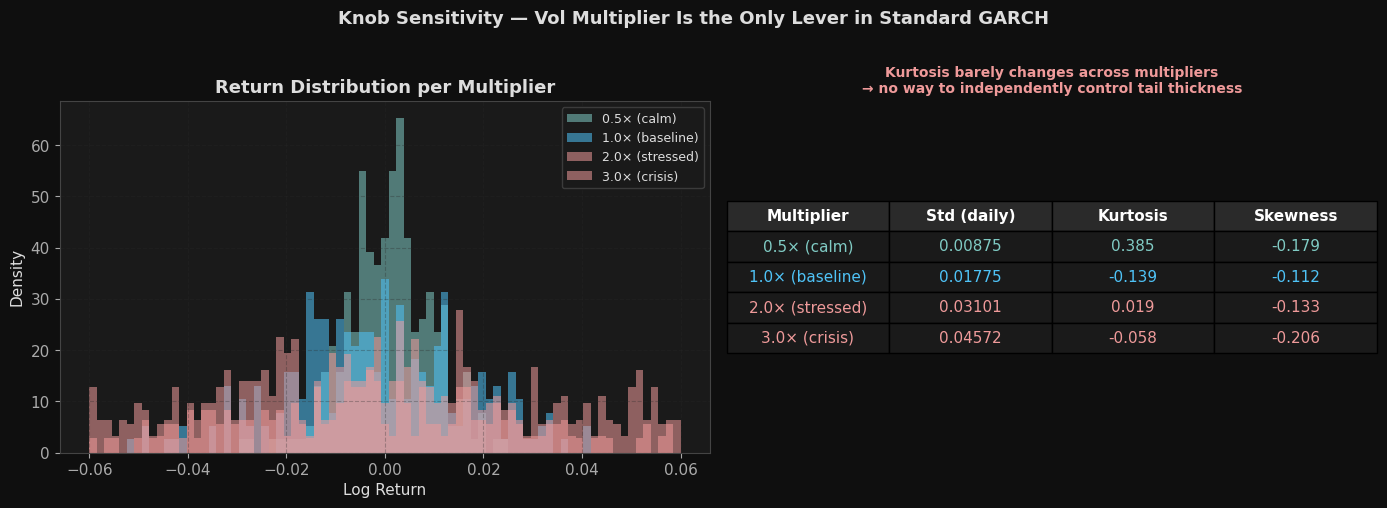


❌ Observation:
   Kurtosis is FIXED regardless of the vol multiplier.
   You can scale returns up or down, but you cannot independently
   change tail behaviour, trend, or momentum — they are all coupled.


In [12]:
def garch_sim_with_vol_multiplier(fitted_result, multiplier, horizon=252, seed=0):
    """Simulate GARCH returns and scale volatility by `multiplier`."""
    np.random.seed(seed)
    sim = fitted_result.forecast(
        horizon=horizon, method="simulation", simulations=1, reindex=False
    )
    r_scaled = sim.simulations.values.flatten()[:horizon]
    v_scaled = np.sqrt(sim.variance.values.flatten()[:horizon])
    r = r_scaled / SCALE
    v = v_scaled / SCALE * multiplier
    # For a fair comparison, we inject the vol multiplier into the returns too
    r = r * multiplier
    return r, v


multipliers = [0.5, 1.0, 2.0, 3.0]
labels = ["0.5× (calm)", "1.0× (baseline)", "2.0× (stressed)", "3.0× (crisis)"]
colors_km = ["#80cbc4", HIST_COLOR, SYNTH_COLOR, RED]

stats_rows = []
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Knob Sensitivity — Vol Multiplier Is the Only Lever in Standard GARCH",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)

bins = np.linspace(-0.06, 0.06, 80)

for m, lab, col in zip(multipliers, labels, colors_km):
    r, _ = garch_sim_with_vol_multiplier(res, m, horizon=HORIZON, seed=42)
    axes[0].hist(r, bins=bins, density=True, alpha=0.55, color=col, label=lab)
    stats_rows.append(
        {
            "Multiplier": lab,
            "Std (daily)": f"{r.std():.5f}",
            "Kurtosis": f"{kurtosis(r):.3f}",
            "Skewness": f"{skew(r):.3f}",
        }
    )

axes[0].set_xlabel("Log Return")
axes[0].set_ylabel("Density")
axes[0].set_title("Return Distribution per Multiplier")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: statistics table
ax2 = axes[1]
ax2.axis("off")

df_stats = pd.DataFrame(stats_rows)
tbl = ax2.table(
    cellText=df_stats.values,
    colLabels=df_stats.columns,
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.0)

for j in range(len(df_stats.columns)):
    tbl[0, j].set_facecolor("#2a2a2a")
    tbl[0, j].set_text_props(color="white", fontweight="bold")

for i, col in enumerate(colors_km):
    for j in range(len(df_stats.columns)):
        tbl[i + 1, j].set_facecolor("#1a1a1a")
        tbl[i + 1, j].set_text_props(color=col)

ax2.set_title(
    "Kurtosis barely changes across multipliers\n"
    "→ no way to independently control tail thickness",
    fontsize=10,
    color=RED,
)

plt.tight_layout()
plt.savefig(
    "reports/stage1_knob_sensitivity.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="#0f0f0f",
)
plt.show()

print("\n❌ Observation:")
print("   Kurtosis is FIXED regardless of the vol multiplier.")
print("   You can scale returns up or down, but you cannot independently")
print("   change tail behaviour, trend, or momentum — they are all coupled.")

---
## 4 · Stage 1 Verdict — Summary

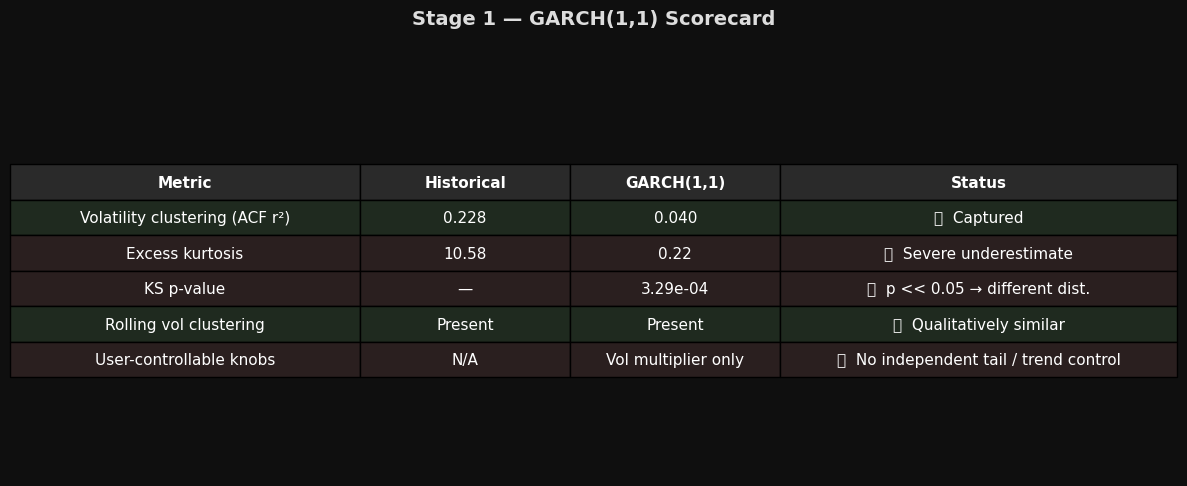


Stage 1 takeaway:
  GARCH(1,1) correctly captures the *structure* of volatility (clustering),
  but the Normal innovation assumption makes tail behaviour too thin.
  More critically, it offers no way for a user to independently control
  volatility magnitude, trend direction, or tail thickness.
  → This motivates Stage 2: Markov Regime-Switching GARCH.


In [13]:
ks_stat_v, ks_pval_v = ks_2samp(
    hist_returns, np.random.choice(synth_returns, size=len(hist_returns), replace=False)
)

h_kurt = kurtosis(hist_returns)
s_kurt = kurtosis(synth_returns)
h_acf1 = acf(hist_returns ** 2, nlags=1, fft=True)[1]
s_acf1 = acf(one_synth_path_r ** 2, nlags=1, fft=True)[1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis("off")

rows = [
    ["Metric", "Historical", "GARCH(1,1)", "Status"],
    ["Volatility clustering (ACF r²)", f"{h_acf1:.3f}", f"{s_acf1:.3f}", "✅  Captured"],
    ["Excess kurtosis", f"{h_kurt:.2f}", f"{s_kurt:.2f}", "❌  Severe underestimate"],
    ["KS p-value", "—", f"{ks_pval_v:.2e}", "❌  p << 0.05 → different dist."],
    ["Rolling vol clustering", "Present", "Present", "✅  Qualitatively similar"],
    [
        "User-controllable knobs",
        "N/A",
        "Vol multiplier only",
        "❌  No independent tail / trend control",
    ],
]

tbl = ax.table(
    cellText=rows[1:],
    colLabels=rows[0],
    loc="center",
    cellLoc="center",
    colWidths=[0.30, 0.18, 0.18, 0.34],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.0)

for j in range(4):
    tbl[0, j].set_facecolor("#2a2a2a")
    tbl[0, j].set_text_props(color="white", fontweight="bold")

status_colors = {
    "✅": "#1f2a1f",
    "❌": "#2a1f1f",
}
for i in range(1, len(rows)):
    status_txt = rows[i][3]
    bg = status_colors.get(status_txt[0], "#1e1e1e")
    for j in range(4):
        tbl[i, j].set_facecolor(bg)
        tbl[i, j].set_text_props(color="white")

ax.set_title("Stage 1 — GARCH(1,1) Scorecard", fontsize=14, fontweight="bold", pad=30)

plt.tight_layout()
plt.savefig(
    "reports/stage1_scorecard.png", dpi=150, bbox_inches="tight", facecolor="#0f0f0f"
)
plt.show()

print("\nStage 1 takeaway:")
print("  GARCH(1,1) correctly captures the *structure* of volatility (clustering),")
print("  but the Normal innovation assumption makes tail behaviour too thin.")
print("  More critically, it offers no way for a user to independently control")
print("  volatility magnitude, trend direction, or tail thickness.")
print("  → This motivates Stage 2: Markov Regime-Switching GARCH.")